# 01 – Utforsking av data og baseline

**Prosjekt:** Diabetes-prediksjon (DAT158, ML assignment 2)
**Datasett:** Pima Indians Diabetes Database (Kaggle / NIDDK), 768 pasienter, 8 features, mål: `Outcome` (1 = diabetes, 0 = ikke diabetes)

Denne notebooken:
1. Laster inn og utforsker dataene (EDA)
2. Avdekker datakvalitetsproblemer (0-verdier som egentlig betyr «mangler»)
3. Deler dataene i trening og test
4. Lager **baseline-ytelse** som de ekte modellene senere må slå

Kjør cellene ovenfra og ned med `Shift + Enter`.

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42  # samme tall overalt, slik at resultatene kan reproduseres

## 1. Last inn data

In [15]:
df = pd.read_csv("../data/diabetes.csv")
print("Antall rader og kolonner:", df.shape)
df.head()

Antall rader og kolonner: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [17]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,120.894531,31.972618,0.000,99.00000,117.0000,140.25000,199.00
BloodPressure,768.0,69.105469,19.355807,0.000,62.00000,72.0000,80.00000,122.00
SkinThickness,768.0,20.536458,15.952218,0.000,0.00000,23.0000,32.00000,99.00
Insulin,768.0,79.799479,115.244002,0.000,0.00000,30.5000,127.25000,846.00
BMI,768.0,31.992578,7.884160,0.000,27.30000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00
Outcome,768.0,0.348958,0.476951,0.000,0.00000,0.0000,1.00000,1.00


## 2. Fordeling av målvariabelen

Er det like mange med og uten diabetes? Hvis ikke, er datasettet *ubalansert*, og accuracy alene kan lure oss.

Outcome
0    500
1    268
Name: count, dtype: int64

Andel med diabetes: 34.9%


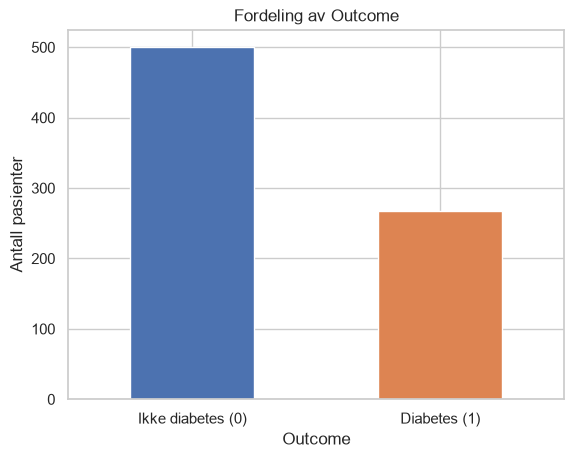

In [18]:
counts = df["Outcome"].value_counts().sort_index()
print(counts)
print("\nAndel med diabetes: {:.1%}".format(df["Outcome"].mean()))

ax = counts.plot(kind="bar", color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["Ikke diabetes (0)", "Diabetes (1)"], rotation=0)
ax.set_ylabel("Antall pasienter")
ax.set_title("Fordeling av Outcome")
plt.show()

## 3. Skjulte manglende verdier

Det er medisinsk umulig å ha blodsukker, blodtrykk, hudtykkelse, insulin eller BMI lik 0.
I dette datasettet betyr 0 i disse kolonnene at verdien **mangler**. Vi teller hvor mange det gjelder.
(`Pregnancies = 0` er derimot en ekte verdi.)

In [19]:
zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

missing = pd.DataFrame({
    "antall_0": (df[zero_cols] == 0).sum(),
    "andel_0": ((df[zero_cols] == 0).mean() * 100).round(1).astype(str) + " %"
})
missing

,antall_0,andel_0
Glucose,5,0.7 %
BloodPressure,35,4.6 %
SkinThickness,227,29.6 %
Insulin,374,48.7 %
BMI,11,1.4 %


**Notat til rapporten (del 2 – Data):** Insulin og SkinThickness mangler for en stor andel av pasientene.
Dette må håndteres i datarensingen, for eksempel ved å erstatte 0 med medianen (beregnet kun på treningsdata).

## 4. Fordeling av hver feature, delt på Outcome

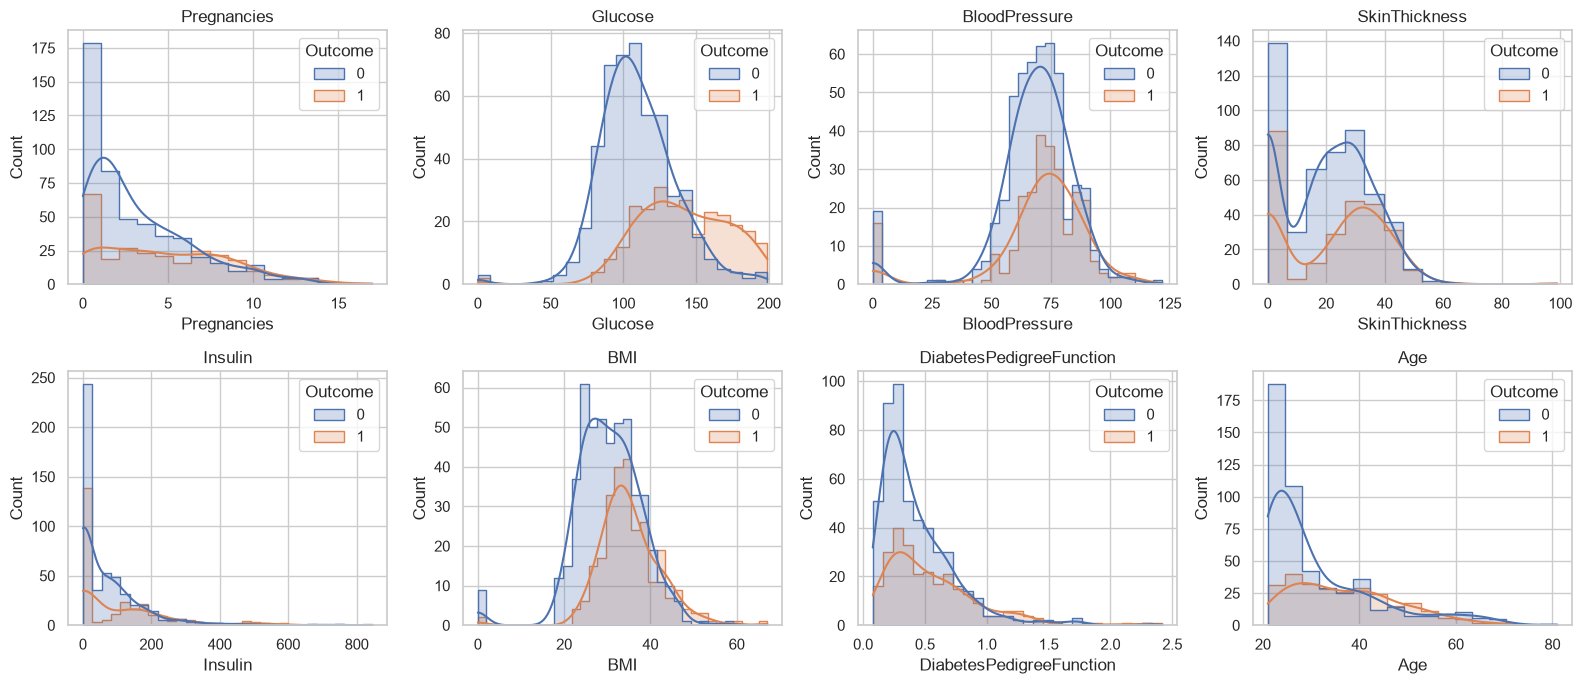

In [20]:
features = df.columns.drop("Outcome")

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, features):
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, ax=ax, element="step")
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 5. Korrelasjon mellom variablene

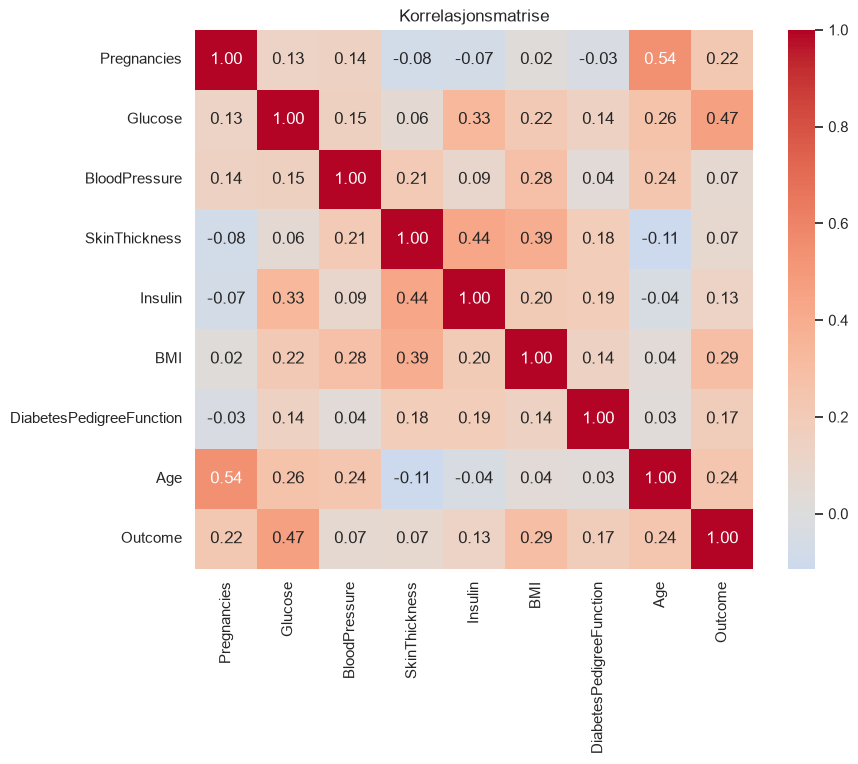

Korrelasjon med Outcome, sortert:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [21]:
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Korrelasjonsmatrise")
plt.show()

print("Korrelasjon med Outcome, sortert:")
print(df.corr()["Outcome"].drop("Outcome").sort_values(ascending=False))

## 6. Del i trening og test

Vi setter av 20 % av dataene som testsett **før** vi gjør noe mer, slik at testsettet aldri påvirker valgene våre.
`stratify=y` sørger for at andelen med diabetes er lik i begge delene.

In [22]:
X = df.drop(columns="Outcome")
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Trening:", X_train.shape, " Test:", X_test.shape)
print("Andel diabetes – trening: {:.1%}, test: {:.1%}".format(y_train.mean(), y_test.mean()))

Trening: (614, 8)  Test: (154, 8)
Andel diabetes – trening: 34.9%, test: 35.1%


## 7. Baseline

Vi lager to enkle baselines som modellene senere må slå:

1. **Gjett alltid flertallsklassen** («ingen har diabetes»). Viser hvorfor accuracy alene er misvisende.
2. **Enkel regel uten maskinlæring:** «diabetes hvis Glucose ≥ terskel». Terskelen velges på treningsdata. Dette ligner hvordan en lege kunne gjort en grov vurdering manuelt.

**Hovedmetrikk: recall** (hvor mange av de syke vi fanger opp), fordi det er verre å overse en person med diabetes enn å gi en falsk alarm. Vi rapporterer også accuracy, precision og F1.

In [23]:
def evaluate(name, y_true, y_pred):
    return {
        "Modell": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
    }

results = []

# Baseline 1: gjett alltid flertallsklassen
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
results.append(evaluate("Baseline: alltid 'ikke diabetes'", y_test, dummy.predict(X_test)))

In [24]:
# Baseline 2: enkel regel på blodsukker. Finn beste terskel (F1) på TRENINGSdata
thresholds = range(80, 200)
f1s = [f1_score(y_train, (X_train["Glucose"] >= t).astype(int)) for t in thresholds]
best_t = list(thresholds)[int(np.argmax(f1s))]
print("Beste terskel på treningsdata: Glucose >=", best_t)

rule_pred = (X_test["Glucose"] >= best_t).astype(int)
results.append(evaluate(f"Baseline: Glucose >= {best_t}", y_test, rule_pred))

Beste terskel på treningsdata: Glucose >= 125


In [25]:
results_df = pd.DataFrame(results).set_index("Modell").round(3)
results_df

,Accuracy,Precision,Recall,F1
Modell,,,,
Baseline: alltid 'ikke diabetes',0.649,0.00,0.00,0.000
Baseline: Glucose >= 125,0.682,0.54,0.63,0.581


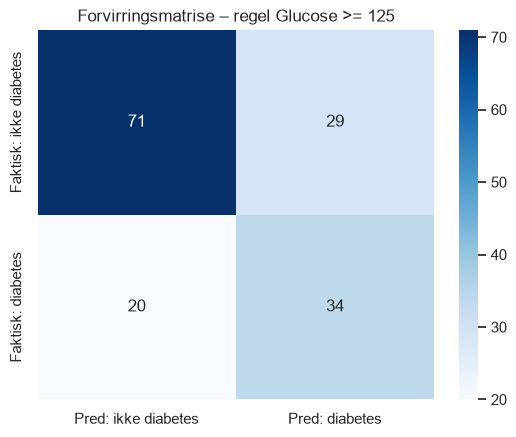

In [26]:
cm = confusion_matrix(y_test, rule_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred: ikke diabetes", "Pred: diabetes"],
            yticklabels=["Faktisk: ikke diabetes", "Faktisk: diabetes"])
plt.title(f"Forvirringsmatrise – regel Glucose >= {best_t}")
plt.show()

## 8. Oppsummering

- Datasettet har 768 pasienter, hvorav 268 (34,9 %) har diabetes → ubalansert.
- Feature med sterkest sammenheng med diabetes: **Glucose** (korrelasjon 0,47), deretter BMI (0,29), Age (0,24) og Pregnancies (0,22).
- Pregnancies og Age korrelerer med hverandre (0,54), og det samme gjør SkinThickness og Insulin (0,44).
- Andel manglende verdier (0): Insulin 374 (48,7 %), SkinThickness 227 (29,6 %), BloodPressure 35 (4,6 %), BMI 11 (1,4 %), Glucose 5 (0,7 %).
- Baseline 1 (flertallsklasse): accuracy 0,649, recall 0,00 → virker grei på accuracy, men finner ingen syke.
- Baseline 2 (Glucose ≥ 125): accuracy 0,682, precision 0,54, recall 0,63, F1 0,581. Regelen overser 20 av 54 syke i testsettet og gir 29 falske alarmer.
- Til sammenligning oppnår andre typisk ca. 75–80 % accuracy på dette datasettet (finn og siter en kilde).

**Neste steg:** notebook 02 – rensing, skalering og trening av ML-modeller som skal slå baseline.